In [ ]:
from google.colab import  drive
drive.mount('/drive')

Mounted at /drive


In [ ]:
!pip install transformers datasets seqeval torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 19.9 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16161 sha256=ffe24283c8a3c7cf3275f875abf34690381bf1985962ff01d0f818a086f783cc
  Stored in directory: /root/.cache/pip/wheels/1a/67/4a/ad4082dd7dfc30f2abfe4d80a2ed5926a506eb8a972b4767fa
Successfully built seqeval
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency 

In [ ]:
import json
import re
import numpy as np
from torch.utils.data import Dataset, DataLoader
import csv
import matplotlib.pyplot as plt
import os
import pandas as pd
import random
import shutil
import torch

from collections import Counter, defaultdict
from datasets import load_dataset, ClassLabel
from seqeval.metrics import classification_report, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.nn.functional import cross_entropy
from torch.optim import AdamW
from torch.utils.data import DataLoader, SubsetRandomSampler
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification, AutoConfig,
    DataCollatorForTokenClassification,
    get_scheduler
)

In [ ]:
def search_entity(sentence):
    e1_matches = re.findall(r'<e1>(.*)</e1>', sentence)
    e2_matches = re.findall(r'<e2>(.*)</e2>', sentence)

    if not e1_matches or not e2_matches:
        # Return None to indicate that the sentence should be skipped
        return None

    e1 = e1_matches[0]
    e2 = e2_matches[0]

    sentence = sentence.replace('<e1>' + e1 + '</e1>', ' <e1> ' + e1 + ' </e1> ', 1)
    sentence = sentence.replace('<e2>' + e2 + '</e2>', ' <e2> ' + e2 + ' </e2> ', 1)
    sentence = sentence.split()
    sentence = ' '.join(sentence)
    sentence = sentence.replace('< e1 >', '<e1>')
    sentence = sentence.replace('< e2 >', '<e2>')
    sentence = sentence.replace('< /e1 >', '</e1>')
    sentence = sentence.replace('< /e2 >', '</e2>')
    sentence = sentence.split()

    assert '<e1>' in sentence
    assert '<e2>' in sentence
    assert '</e1>' in sentence
    assert '</e2>' in sentence

    return sentence


def convert(path_src, path_des):
    with open(path_src, 'r', encoding='utf-8') as fr:
        data = fr.readlines()

    with open(path_des, 'w', encoding='utf-8') as fw:
        for i in range(0, len(data), 3):
            id_s, sentence = data[i].strip().split('  ')
            sentence = sentence[1:-1]

            # Process sentence using search_entity function
            sentence = search_entity(sentence)

            # Check if search_entity returned None
            if sentence is None:
                # Skip processing
                continue

            # Create a dictionary with metadata
            meta = dict(
                id=id_s,
                relation=data[i+1].strip(),
                sentence=sentence,
                comment=data[i+2].strip()
            )

            # Write the dictionary as a JSON object
            json.dump(meta, fw, ensure_ascii=False)

            fw.write('\n')


In [ ]:
#my_path = "/drive/MyDrive/datasets/relations_extraction/dnrti_re/"
my_path = "/drive/MyDrive/datasets/relations_extraction/dnrti_aug_re/"

In [ ]:
# path_train = my_path + 'pre_train.txt'
# path_test = my_path +'pre_test.txt'
# path_valid = my_path +'pre_test.txt'

# # # # path_train = my_path + 'pre_train.txt'
# # # # convert(path_train, my_path + '/pre_train1.json')

# convert(path_train, my_path + '/train.json')
# convert(path_test, my_path +'/test.json')
# convert(path_test, my_path +'/valid.json')

In [ ]:
OUTPUT_FILEPATHS = [
  os.path.join(my_path, "train.json"),
  os.path.join(my_path, "test.json"),
  os.path.join(my_path, "valid.json")
]

In [ ]:
data_files = {
    "train": OUTPUT_FILEPATHS[0],
    "validation": OUTPUT_FILEPATHS[1],
    "test": OUTPUT_FILEPATHS[2]
}
dataset = load_dataset("json", data_files=data_files)
dataset

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'relation', 'sentence', 'comment'],
        num_rows: 26544
    })
    validation: Dataset({
        features: ['id', 'relation', 'sentence', 'comment'],
        num_rows: 8849
    })
    test: Dataset({
        features: ['id', 'relation', 'sentence', 'comment'],
        num_rows: 8849
    })
})

In [ ]:
dataset["train"][2]

{'id': '3',
 'relation': 'targets(e1,e2)',
 'sentence': ['"These',
  'samples',
  'appeared',
  'to',
  'have',
  'been',
  'created',
  'by',
  'oilrig',
  'during',
  'their',
  'development',
  'and',
  'testing',
  'activities,',
  'all',
  'of',
  'which',
  'share',
  'many',
  'similarities',
  'with',
  'the',
  'delivery',
  'document',
  'used',
  'in',
  'the',
  'recent',
  '<e1>',
  'oilrig',
  'attack',
  '</e1>',
  'against',
  'a',
  'middle',
  'eastern',
  '<e2>',
  'government',
  '</e2>',
  ',',
  'n56.15.doc(',
  '7cbad6b3f505a199d6766a86b41ed23786bbb99dab9cae6c18936afdc2512f00)',
  'that',
  'we',
  'have',
  'also',
  'included',
  'in',
  'table',
  '1.'],
 'comment': ''}

In [ ]:
from transformers import RobertaTokenizerFast, RobertaModel

In [ ]:
BASE_MODEL_NAME = "ehsanaghaei/SecureBERT"
#BASE_MODEL_NAME = "roberta-base"
tokenizer = RobertaTokenizerFast.from_pretrained(BASE_MODEL_NAME, add_prefix_space=True)

# Add special tokens
special_tokens_dict = {'additional_special_tokens': ['<e1>', '</e1>', '<e2>', '</e2>']}
num_added_toks = tokenizer.add_special_tokens(special_tokens_dict)
print("We have added", num_added_toks, "tokens")

# Load the model
model = RobertaModel.from_pretrained(BASE_MODEL_NAME)
model.resize_token_embeddings(len(tokenizer))


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/815k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/473k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

...

We have added 4 tokens


config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at ehsanaghaei/SecureBERT and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Embedding(50269, 768, padding_idx=1)

In [ ]:
e1_id = tokenizer.convert_tokens_to_ids('<e1>')
e2_id = tokenizer.convert_tokens_to_ids('<e2>')
close_e1_id = tokenizer.convert_tokens_to_ids('</e1>')
close_e2_id = tokenizer.convert_tokens_to_ids('</e2>')

print("ID for '<e1>':", e1_id)
print("ID for '</e1>':", close_e1_id)
print("ID for '<e2>':", e2_id)
print("ID for '</e2>':", close_e2_id)

ID for '<e1>': 50265
ID for '</e1>': 50266
ID for '<e2>': 50267
ID for '</e2>': 50268


In [ ]:
Sentence:  "  highnoon , one of the main code families observed being used by apt41, was also used by apt17 in 2015 to target  semiconductor  and chemical manufacturers."

In [ ]:
def clean_sentence(sentence):
    if sentence:
        # Check if the first token starts with "
        if sentence[0].startswith('"'):
            sentence[0] = sentence[0][1:]  # Remove the " from the start of the first token
    return sentence
def clean_example(example):
    example['sentence'] = clean_sentence(example['sentence'])
    return example
dataset = dataset.map(clean_example)

Map:   0%|          | 0/26544 [00:00<?, ? examples/s]

Map:   0%|          | 0/8849 [00:00<?, ? examples/s]

Map:   0%|          | 0/8849 [00:00<?, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'relation', 'sentence', 'comment'],
        num_rows: 26544
    })
    validation: Dataset({
        features: ['id', 'relation', 'sentence', 'comment'],
        num_rows: 8849
    })
    test: Dataset({
        features: ['id', 'relation', 'sentence', 'comment'],
        num_rows: 8849
    })
})

In [ ]:
tokens = tokenizer(dataset["train"][0]["sentence"], is_split_into_words=True).tokens()
tokens

['<s>',
 'ĠThe',
 'Ġmiddle',
 'Ġeastern',
 'Ġgroup',
 'Ġin',
 'Ġthis',
 'Ġcase',
 'Ġis',
 'Ġcodenamed',
 '"',
 '<e1>',
 'Ġblack',
 'o',
 'asis',
 '</e1>',
 'Ġ"',
 'Ġk',
 'aspersky',
 'Ġfound',
 'Ġthe',
 'Ġhacker',
 'Ġgroup',
 'Ġwas',
 'Ġexploiting',
 'Ġa',
 '<e2>',
 'Ġad',
 'obe',
 'Ġflash',
 'Ġplayer',
 'Ġzero',
 '-',
 'day',
 'Ġvulnerability',
 '</e2>',
 'Ġ(',
 'Ġc',
 've',
 '-',
 '2016',
 '-',
 '4',
 '117',
 ')',
 'Ġto',
 'Ġremotely',
 'Ġdeliver',
 'Ġthe',
 'Ġlatest',
 'Ġversion',
 'Ġof',
 '"',
 'Ġfin',
 'spy',
 '"',
 'Ġmalware',
 ',',
 'Ġaccording',
 'Ġto',
 'Ġa',
 'Ġnew',
 'Ġblog',
 'Ġpost',
 'Ġpublished',
 'Ġm',
 'ond',
 'ay',
 '.',
 '</s>']

In [ ]:
input = tokenizer(dataset["train"][0]["sentence"], is_split_into_words=True)
word_ids = input.word_ids()
pd.DataFrame([tokens, word_ids], index=["sentence", "word_ids"])

,0,1,2,3,4,5,6,7,8,9,...,60,61,62,63,64,65,66,67,68,69
sentence,<s>,ĠThe,Ġmiddle,Ġeastern,Ġgroup,Ġin,Ġthis,Ġcase,Ġis,Ġcodenamed,...,Ġa,Ġnew,Ġblog,Ġpost,Ġpublished,Ġm,ond,ay,.,</s>
word_ids,None,0,1,2,3,4,5,6,7,8,...,41,42,43,44,45,46,46,46,46,None


In [ ]:
model.save_pretrained('my_model_directory/')  # Save the model and tokenizer
tokenizer.save_pretrained('my_model_directory/')

('my_model_directory/tokenizer_config.json',
 'my_model_directory/special_tokens_map.json',
 'my_model_directory/vocab.json',
 'my_model_directory/merges.txt',
 'my_model_directory/added_tokens.json',
 'my_model_directory/tokenizer.json')

# Tokenization

In [ ]:
BASE_MODEL_NAME = 'my_model_directory/'
tokenizer = RobertaTokenizerFast.from_pretrained(BASE_MODEL_NAME, add_prefix_space=True)

In [ ]:
def tokenize_function(examples):
    # Process each sentence in the batch
    sentences = [' '.join(sentence) for sentence in examples['sentence']]
    return tokenizer(sentences, padding="max_length", truncation=True, max_length=100)

# Apply the tokenizer across the dataset in batches
tokenized_datasets = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/26544 [00:00<?, ? examples/s]

Map:   0%|          | 0/8849 [00:00<?, ? examples/s]

Map:   0%|          | 0/8849 [00:00<?, ? examples/s]

In [ ]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['id', 'relation', 'sentence', 'comment', 'input_ids', 'attention_mask'],
        num_rows: 26544
    })
    validation: Dataset({
        features: ['id', 'relation', 'sentence', 'comment', 'input_ids', 'attention_mask'],
        num_rows: 8849
    })
    test: Dataset({
        features: ['id', 'relation', 'sentence', 'comment', 'input_ids', 'attention_mask'],
        num_rows: 8849
    })
})

In [ ]:
tokenized_datasets["train"][0]

{'id': '1',
 'relation': 'targets(e1,e2)',
 'sentence': ['The',
  'middle',
  'eastern',
  'group',
  'in',
  'this',
  'case',
  'is',
  'codenamed"',
  '<e1>',
  'blackoasis',
  '</e1>',
  '"',
  'kaspersky',
  'found',
  'the',
  'hacker',
  'group',
  'was',
  'exploiting',
  'a',
  '<e2>',
  'adobe',
  'flash',
  'player',
  'zero-day',
  'vulnerability',
  '</e2>',
  '(',
  'cve-2016-4117)',
  'to',
  'remotely',
  'deliver',
  'the',
  'latest',
  'version',
  'of"',
  'finspy"',
  'malware,',
  'according',
  'to',
  'a',
  'new',
  'blog',
  'post',
  'published',
  'monday.'],
 'comment': '',
 'input_ids': [0,
  20,
  1692,
  4580,
  333,
  11,
  42,
  403,
  16,
  21152,
  113,
  1437,
  50265,
  909,
  139,
  17048,
  1437,
  50266,
  22,
  449,
  37164,
  303,
  5,
  26457,
  333,
  21,
  26005,
  10,
  1437,
  50267,
  2329,
  14004,
  7462,
  869,
  4276,
  12,
  1208,
  15661,
  1437,
  50268,
  36,
  740,
  548,
  12,
  9029,
  12,
  306,
  21598,
  43,
  7,
  18684,
 

In [ ]:
def create_relation_file(relations, data_dir=my_path):
    relation_file = os.path.join(data_dir, 'relation2id.txt')

    # Create a mapping between relations and IDs
    rel2id = {rel: str(idx) for idx, rel in enumerate(relations)}

    # Create the reverse mapping (ID to relation)
    id2rel = {str(idx): rel for idx, rel in enumerate(relations)}

    # Write the mapping to the relation2id.txt file
    with open(relation_file, 'w', encoding='utf-8') as fw:
        for rel, rel_id in rel2id.items():
            fw.write(f"{rel}\t{rel_id}\n")

    return rel2id, id2rel

In [ ]:
unique_relations = ['UKN', '<PAD>', 'targets(e1,e2)', 'uses(e1,e2)', 'targetedBy(e1,e2)',
       'hasAttackLocation(e1,e2)', 'hasLocation(e1,e2)',
       'associatedWith(e1,e2)', 'hasAttackTime(e1,e2)',
       'identifies(e1,e2)', 'monitors(e1,e2)', 'usedBy(e1,e2)',
       'affiliatedWith(e1,e2)', 'hasVulnerability(e1,e2)',
       'monitoredBy(e1,e2)', 'identifiedBy(e1,e2)', 'contains(e1,e2)']


#Normalized Dataset

# unique_relations = ['UKN', '<PAD>', 'targets(e1,e2)', 'uses(e1,e2)', 'targetedBy(e1,e2)',
#        'locatedAt(e1,e2)', 'hasAttackTime(e1,e2)', 'usedBy(e1,e2)',
#        'hasCharacteristics(e1,e2)', 'associatedWith(e1,e2)',
#        'discovers(e1,e2)', 'monitors(e1,e2)', 'motivatedBy(e1,e2)',
#        'discoveredBy(e1,e2)', 'monitoredBy(e1,e2)', 'motivates(e1,e2)',
#        'analyses(e1,e2)']

rel2id, id2rel = create_relation_file(unique_relations)

print("rel2id:", rel2id)
print("id2rel:", id2rel)

rel2id: {'UKN': '0', '<PAD>': '1', 'targets(e1,e2)': '2', 'uses(e1,e2)': '3', 'targetedBy(e1,e2)': '4', 'hasAttackLocation(e1,e2)': '5', 'hasLocation(e1,e2)': '6', 'associatedWith(e1,e2)': '7', 'hasAttackTime(e1,e2)': '8', 'identifies(e1,e2)': '9', 'monitors(e1,e2)': '10', 'usedBy(e1,e2)': '11', 'affiliatedWith(e1,e2)': '12', 'hasVulnerability(e1,e2)': '13', 'monitoredBy(e1,e2)': '14', 'identifiedBy(e1,e2)': '15', 'contains(e1,e2)': '16'}
id2rel: {'0': 'UKN', '1': '<PAD>', '2': 'targets(e1,e2)', '3': 'uses(e1,e2)', '4': 'targetedBy(e1,e2)', '5': 'hasAttackLocation(e1,e2)', '6': 'hasLocation(e1,e2)', '7': 'associatedWith(e1,e2)', '8': 'hasAttackTime(e1,e2)', '9': 'identifies(e1,e2)', '10': 'monitors(e1,e2)', '11': 'usedBy(e1,e2)', '12': 'affiliatedWith(e1,e2)', '13': 'hasVulnerability(e1,e2)', '14': 'monitoredBy(e1,e2)', '15': 'identifiedBy(e1,e2)', '16': 'contains(e1,e2)'}


In [ ]:
len(rel2id)

17

In [ ]:
class RoBERTaBrevetsDataset(Dataset):
    def __init__(self, filename, rel2id, tokenizer, max_len):
        self.filename = os.path.join(my_path, filename)
        self.rel2id = rel2id
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.dataset, self.label = self.__load_data()

    def __load_data(self):
        data = []
        labels = []
        with open(self.filename, 'r', encoding='utf-8') as fr:
            for line in fr:
                line = json.loads(line.strip())
                label = self.rel2id[line['relation']]
                sentence = ' '.join(line['sentence'])  # Join tokens to form a single string
                label_idx = int(label)

                # Tokenize and encode the sentence
                inputs = self.tokenizer(sentence, max_length=self.max_len, padding='max_length', truncation=True, return_tensors="pt")
                inputs = {key: tensor.squeeze(0) for key, tensor in inputs.items()}  # Remove batch dimension

                # Create a label sequence of the same length as the input
                label_seq = torch.full((self.max_len,), label_idx, dtype=torch.long)

                data.append(inputs)
                labels.append(label_seq)
        return data, labels

    def __getitem__(self, index):
        inputs = self.dataset[index]
        label = self.label[index]
        return inputs, label

    def __len__(self):
        return len(self.label)

class RoBERTaBrevetsDataLoader(object):
    def __init__(self, rel2id, tokenizer, batch_size, max_len):
        self.rel2id = rel2id
        self.tokenizer = tokenizer
        self.batch_size = batch_size
        self.max_len = max_len

    def __collate_fn(self, batch):
        input_ids = torch.stack([item[0]['input_ids'] for item in batch])
        attention_mask = torch.stack([item[0]['attention_mask'] for item in batch])
        labels = torch.stack([item[1] for item in batch])

        return {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': labels}

    def __get_data(self, filename, shuffle=False):
        dataset = RoBERTaBrevetsDataset(filename, self.rel2id, self.tokenizer, self.max_len)
        loader = DataLoader(
            dataset=dataset,
            batch_size=self.batch_size,
            shuffle=shuffle,
            collate_fn=self.__collate_fn
        )
        return loader

    def get_train(self):
        return self.__get_data('train.json', shuffle=True)

    def get_dev(self):
        return self.__get_data('valid.json', shuffle=False)

    def get_test(self):
        return self.__get_data('test.json', shuffle=False)


In [ ]:
batch_size = 16
max_len = 150
loader = RoBERTaBrevetsDataLoader(rel2id, tokenizer, batch_size, max_len)
test_loader = loader.get_test()
train_loader = loader.get_train()
valid_loader = loader.get_dev()

In [ ]:
train_loader

In [ ]:
# Verify data loader output
for batch in train_loader:
    print(batch)
    break

{'input_ids': tensor([[    0,    22, 41967,  ...,     1,     1,     1],
        [    0,    22,   170,  ...,     1,     1,     1],
        [    0,    22, 38243,  ...,     1,     1,     1],
        ...,
        [    0,    22,   133,  ...,     1,     1,     1],
        [    0,    22,  7605,  ...,     1,     1,     1],
        [    0,    22, 21461,  ...,     1,     1,     1]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]]), 'labels': tensor([[11, 11, 11,  ..., 11, 11, 11],
        [ 4,  4,  4,  ...,  4,  4,  4],
        [ 3,  3,  3,  ...,  3,  3,  3],
        ...,
        [ 7,  7,  7,  ...,  7,  7,  7],
        [ 3,  3,  3,  ...,  3,  3,  3],
        [ 6,  6,  6,  ...,  6,  6,  6]])}


In [ ]:
for batch in test_loader:
    input_ids = batch['input_ids']
    attention_mask = batch['attention_mask']
    labels = batch['labels']

    print("Input IDs:", input_ids)
    print("Attention Mask:", attention_mask)
    print("Labels:", labels)
    print("Input IDs shape:", input_ids.shape)
    print("Attention Mask shape:", attention_mask.shape)
    print("Labels shape:", labels.shape)
    break

Input IDs: tensor([[    0,    22,  2709,  ...,     1,     1,     1],
        [    0,    22,   133,  ...,     1,     1,     1],
        [    0,    22,   170,  ...,     1,     1,     1],
        ...,
        [    0,    22,  1121,  ...,     1,     1,     1],
        [    0,    22, 11321,  ...,     1,     1,     1],
        [    0,    22,   133,  ...,     1,     1,     1]])
Attention Mask: tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])
Labels: tensor([[5, 5, 5,  ..., 5, 5, 5],
        [2, 2, 2,  ..., 2, 2, 2],
        [5, 5, 5,  ..., 5, 5, 5],
        ...,
        [5, 5, 5,  ..., 5, 5, 5],
        [5, 5, 5,  ..., 5, 5, 5],
        [3, 3, 3,  ..., 3, 3, 3]])
Input IDs shape: torch.Size([16, 150])
Attention Mask shape: torch.Size([16, 150])
Labels shape: torch.Size([16, 150])


In [ ]:
!pip install pytorch-crf

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
import torch
from torch import nn
from transformers import RobertaModel
from torchcrf import CRF

class RobertaBiGRUCRF(nn.Module):
    def __init__(self, model_name, num_labels, hidden_dim=256, dropout_prob=0.3):
        super(RobertaBiGRUCRF, self).__init__()
        self.roberta = RobertaModel.from_pretrained(model_name)
        self.gru = nn.GRU(self.roberta.config.hidden_size, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_dim * 2, num_labels)  # BiGRU output size is hidden_dim*2
        self.crf = CRF(num_labels, batch_first=True)

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.roberta(input_ids, attention_mask=attention_mask)
        sequence_output = outputs[0]  # Last hidden state

        # Apply dropout to the sequence output
        sequence_output = self.dropout(sequence_output)

        gru_output, _ = self.gru(sequence_output)

        # Apply dropout to the GRU output
        gru_output = self.dropout(gru_output)

        emissions = self.fc(gru_output)

        if labels is not None:
            # Calculate the loss
            loss = -self.crf(emissions, labels, mask=attention_mask.bool(), reduction='mean')
            return loss
        else:
            # Decode the sequence
            prediction = self.crf.decode(emissions, mask=attention_mask.bool())
            return prediction


In [ ]:
# import torch
# from torch import nn
# from transformers import RobertaModel
# from torchcrf import CRF

# class Attention(nn.Module):
#     def __init__(self, hidden_dim):
#         super(Attention, self).__init__()
#         self.attention = nn.Linear(hidden_dim * 2, hidden_dim * 2)
#         self.context_vector = nn.Parameter(torch.rand(hidden_dim * 2))

#     def forward(self, gru_output):
#         # Compute attention scores
#         attention_scores = torch.tanh(self.attention(gru_output))
#         attention_weights = torch.matmul(attention_scores, self.context_vector)
#         attention_weights = torch.softmax(attention_weights, dim=1)

#         # Apply attention weights
#         context_vector = attention_weights.unsqueeze(-1) * gru_output
#         context_vector = torch.sum(context_vector, dim=1)
#         return context_vector

# class RobertaBiGRUCRF(nn.Module):
#     def __init__(self, model_name, num_labels, hidden_dim=256, dropout_prob=0.3):
#         super(RobertaBiGRUCRF, self).__init__()
#         self.roberta = RobertaModel.from_pretrained(model_name)
#         self.gru = nn.GRU(self.roberta.config.hidden_size, hidden_dim, batch_first=True, bidirectional=True)
#         self.attention = Attention(hidden_dim)
#         self.dropout = nn.Dropout(dropout_prob)
#         self.fc = nn.Linear(hidden_dim * 2, num_labels)  # BiGRU output size is hidden_dim*2
#         self.crf = CRF(num_labels, batch_first=True)

#     def forward(self, input_ids, attention_mask, labels=None):
#         outputs = self.roberta(input_ids, attention_mask=attention_mask)
#         sequence_output = outputs[0]  # Last hidden state

#         # Apply dropout to the sequence output
#         sequence_output = self.dropout(sequence_output)

#         gru_output, _ = self.gru(sequence_output)

#         # Apply dropout to the GRU output
#         gru_output = self.dropout(gru_output)

#         # Apply attention to the GRU output, keeping the sequence dimension
#         attention_weights = torch.tanh(self.attention.attention(gru_output))
#         attention_weights = torch.matmul(attention_weights, self.attention.context_vector)
#         attention_weights = torch.softmax(attention_weights, dim=1).unsqueeze(-1)

#         # Use attention weights to create a weighted sum of the GRU output
#         context_vector = attention_weights * gru_output
#         emissions = self.fc(context_vector)

#         if labels is not None:
#             # Calculate the loss
#             loss = -self.crf(emissions, labels, mask=attention_mask.bool(), reduction='mean')
#             return loss
#         else:
#             # Decode the sequence
#             prediction = self.crf.decode(emissions, mask=attention_mask.bool())
#             return prediction


In [ ]:
# Example usage
model_name = 'my_model_directory/'
num_labels = len(unique_relations)  # Adjust this based on your relation count
model = RobertaBiGRUCRF(model_name, num_labels)
model.to(device)

# Sample forward pass
sample_batch = next(iter(train_loader))
input_ids = sample_batch['input_ids'].to(device)
attention_mask = sample_batch['attention_mask'].to(device)
labels = sample_batch['labels'].to(device)

# For training
model.train()
loss = model(input_ids, attention_mask, labels)
print("Training loss:", loss.item())

# For inference
model.eval()
with torch.no_grad():
    predictions = model(input_ids, attention_mask)
print("Predictions:", predictions)


Training loss: 167.5433807373047
Predictions: [[16, 12, 12, 16, 16, 4, 12, 15, 12, 15, 16, 16, 16, 12, 12, 12, 15, 2, 13, 2, 9, 16, 16, 16, 4, 12, 12, 16, 4, 2, 9, 16, 6, 16, 16, 16, 6, 16, 6, 6, 6, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 12, 12, 12, 15, 2, 13, 2, 15, 6, 16, 16, 16, 12, 12, 12, 12, 12, 15, 16, 4, 2, 0, 13, 2, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 12, 12, 12, 12, 12, 15, 2, 9, 16, 16, 12, 12, 12, 12, 12, 15, 2, 9, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 12, 12, 12, 12, 15, 2, 13, 2, 9, 16, 16, 16, 4, 2, 9, 16, 4, 2, 9, 16, 16, 12, 12, 12, 15, 12, 15, 2, 15, 15, 2], [16, 12, 12, 12, 12, 12, 12, 16, 16, 6, 6, 6, 6, 6, 16, 16, 16, 16, 16, 16, 16, 16, 16, 12, 12, 12, 12, 12, 16, 16, 12, 12, 15, 2, 0, 13, 2, 13, 2, 0, 13, 2, 9, 16, 16, 6, 16, 16, 16, 16, 6, 16, 16, 12, 12, 12, 16, 4, 2], [16, 16, 16, 16, 16, 16, 4, 2, 4, 2, 13, 2, 4, 2, 15, 6, 6, 16, 4, 2, 13, 2, 13, 2, 6, 16, 16, 16, 12, 15, 12, 15, 2, 13, 2, 13, 2, 6, 16, 16, 16, 6, 6, 16, 16, 4, 

# Model Architecture

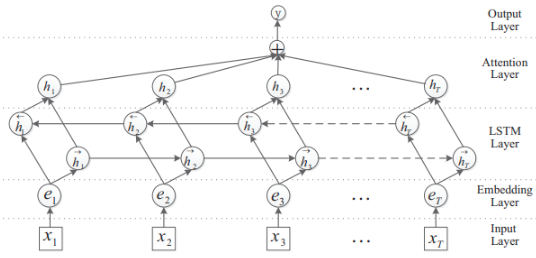

In [ ]:
#class_num = len(rel2id)
class_num = len(rel2id) + 1

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

def calculate_f1_scores(predicted_labels, true_labels):
    # Calculate F1 scores
    micro_f1 = f1_score(true_labels, predicted_labels, average='micro')
    macro_f1 = f1_score(true_labels, predicted_labels, average='macro')

    return micro_f1, macro_f1

In [ ]:
import torch
from torch import nn
from transformers import get_scheduler
from sklearn.metrics import f1_score
import time

def train_model(model, iterator, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in iterator:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        # Compute loss
        loss = model(input_ids, attention_mask, labels)
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        with torch.no_grad():
            preds = model(input_ids, attention_mask)
            for pred, label, mask in zip(preds, labels, attention_mask):
                active_labels = label[mask == 1]
                all_labels.extend(active_labels.cpu().numpy())
                all_preds.extend(pred[:len(active_labels)])

    avg_loss = total_loss / len(iterator)
    micro_f1 = f1_score(all_labels, all_preds, average='micro')
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    return micro_f1, macro_f1, avg_loss

def evaluate(model, iterator, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in iterator:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Compute loss
            loss = model(input_ids, attention_mask, labels)
            total_loss += loss.item()

            preds = model(input_ids, attention_mask)

            for pred, label, mask in zip(preds, labels, attention_mask):
                active_labels = label[mask == 1]
                all_labels.extend(active_labels.cpu().numpy())
                all_preds.extend(pred[:len(active_labels)])

    avg_loss = total_loss / len(iterator)
    micro_f1 = f1_score(all_labels, all_preds, average='micro')
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    return micro_f1, macro_f1, avg_loss, all_preds, all_labels

def entrainement(model, train_loader, valid_loader, optimizer, scheduler, criterion, device, N_EPOCHS, model_path='model.pt'):
    t_loss = []
    t_micro_f1 = []
    t_macro_f1 = []
    v_loss = []
    v_micro_f1 = []
    v_macro_f1 = []
    best_valid_loss = float('inf')

    for epoch in range(N_EPOCHS):
        start_time = time.time()

        train_micro_f1, train_macro_f1, train_loss = train_model(model, train_loader, optimizer, scheduler, criterion, device)
        t_loss.append(train_loss)
        t_micro_f1.append(train_micro_f1)
        t_macro_f1.append(train_macro_f1)

        valid_micro_f1, valid_macro_f1, valid_loss, all_preds, all_labels = evaluate(model, valid_loader, criterion, device)
        v_loss.append(valid_loss)
        v_micro_f1.append(valid_micro_f1)
        v_macro_f1.append(valid_macro_f1)

        end_time = time.time()

        epoch_mins, epoch_secs = epoch_time(start_time, end_time)

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), model_path)

        print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
        print(f'\tTrain Loss: {train_loss:.3f} | Train Micro F1: {train_micro_f1*100:.2f}% | Train Macro F1: {train_macro_f1*100:.2f}%')
        print(f'\tVal. Loss: {valid_loss:.3f} | Val. Micro F1: {valid_micro_f1*100:.2f}% | Val. Macro F1: {valid_macro_f1*100:.2f}%')

    return t_loss, v_loss, t_micro_f1, v_micro_f1, t_macro_f1, v_macro_f1

def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs


In [ ]:
from torch.optim.lr_scheduler import OneCycleLR

In [ ]:
# Example usage
model_name = 'my_model_directory/'
num_labels = len(unique_relations)  # Adjust this based on your relation count
model = RobertaBiGRUCRF(model_name, num_labels, dropout_prob=0.3)
model.to(device)

N_EPOCHS = 3
# optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
# scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=len(train_loader) * N_EPOCHS)
criterion = None  # Not used, as CRF handles the loss internall



optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
scheduler = OneCycleLR(optimizer, max_lr=5e-5, steps_per_epoch=len(train_loader), epochs=N_EPOCHS)


In [ ]:
t_loss, v_loss, t_micro_f1, v_micro_f1, t_macro_f1, v_macro_f1 = entrainement(
    model, train_loader, valid_loader, optimizer, scheduler, criterion, device, N_EPOCHS, model_path='model.pt'
)


Epoch: 01 | Epoch Time: 21m 57s
	Train Loss: 63.880 | Train Micro F1: 66.24% | Train Macro F1: 51.14%
	Val. Loss: 22.255 | Val. Micro F1: 88.93% | Val. Macro F1: 80.79%
Epoch: 02 | Epoch Time: 21m 55s
	Train Loss: 17.515 | Train Micro F1: 94.28% | Train Macro F1: 92.89%
	Val. Loss: 18.043 | Val. Micro F1: 94.81% | Val. Macro F1: 93.40%
Epoch: 03 | Epoch Time: 21m 58s
	Train Loss: 10.632 | Train Micro F1: 97.10% | Train Macro F1: 96.41%
	Val. Loss: 16.619 | Val. Micro F1: 96.08% | Val. Macro F1: 95.01%


In [ ]:
#print(model.config)

In [ ]:
#N_EPOCHS = 6

In [ ]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Number of trainable parameters: {total_params:,}')

count_parameters(model)

Number of trainable parameters: 126,233,684


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.set()

def plot_metrics(N_EPOCHS, t_loss, v_loss, t_micro_f1, v_micro_f1, t_macro_f1, v_macro_f1):
    f = plt.figure(figsize=(6, 7))  # Increase figure size for better visibility
    gs = f.add_gridspec(3, 1)  # Add an additional grid for macro F1 scores
    plt.subplots_adjust(hspace=0.4)  # Adjust horizontal space
    x = np.linspace(0, N_EPOCHS, N_EPOCHS)

    # Plotting Loss
    with sns.axes_style("darkgrid"):
        ax = f.add_subplot(gs[0])
        plt.plot(x, t_loss, label='Train Loss')
        plt.plot(x, v_loss, label='Valid Loss')
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()
        plt.title("Training and Validation Loss")

    # Plotting Micro F1 Score
    ax = f.add_subplot(gs[1])
    plt.plot(x, t_micro_f1, label='Train F1 Score')
    plt.plot(x, v_micro_f1, label='Valid F1 Score')
    plt.xlabel("Epochs")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.title("Training and Validation F1 Score")

    # Plotting Macro F1 Score
    # ax = f.add_subplot(gs[2])
    # plt.plot(x, t_macro_f1, label='Train Macro F1 Score')
    # plt.plot(x, v_macro_f1, label='Valid Macro F1 Score')
    # plt.xlabel("Epochs")
    # plt.ylabel("Macro F1 Score")
    # plt.legend()
    # plt.title("Training and Validation Macro F1 Score")

    f.tight_layout()  # Adjust layout to fit all subplots neatly
    plt.show()


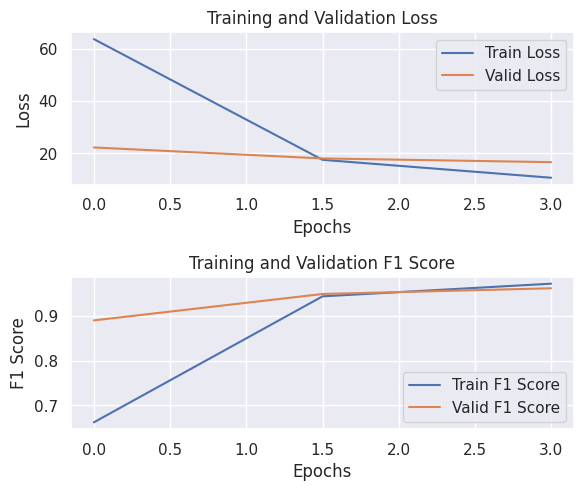

In [ ]:
# Call the function with the appropriate arguments
plot_metrics(N_EPOCHS, t_loss, v_loss, t_micro_f1, v_micro_f1, t_macro_f1, v_macro_f1)

In [ ]:
import torch

model_path ='/content/model.pt'


model.load_state_dict(torch.load(model_path))
model.to(device)

micro_f1, macro_f1, eval_loss, preds, labels = evaluate(model, test_loader, criterion, device)

# Print the evaluation results
print(f'Test Loss: {eval_loss:.3f}')
print(f'Test Micro F1 Score: {micro_f1*100:.2f}%')
print(f'Test Macro F1 Score: {macro_f1*100:.2f}%')

<ipython-input-47-2f8477cc55d6>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Test Loss: 16.619
Test Micro F1 Score: 96.08%
Test Macro F1 Score: 95.01%


In [ ]:
tokenizer

RobertaTokenizerFast(name_or_path='my_model_directory/', vocab_size=50265, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>', 'additional_special_tokens': ['<e1>', '</e1>', '<e2>', '</e2>']}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	50264: AddedToken("<mask>", rstrip=False, lstrip=True, single_word=False, normalized=True, special=True),
	50265: AddedToken("<e1>", rstrip=F

In [ ]:
def evaluate(model, iterator, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in iterator:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Compute loss
            loss = model(input_ids, attention_mask, labels)
            total_loss += loss.item()

            preds = model(input_ids, attention_mask)

            for pred, label, mask in zip(preds, labels, attention_mask):
                active_labels = label[mask == 1]
                all_labels.extend(active_labels.cpu().numpy())
                all_preds.extend(pred[:len(active_labels)])

    avg_loss = total_loss / len(iterator)
    micro_f1 = f1_score(all_labels, all_preds, average='micro')
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    return micro_f1, macro_f1, avg_loss, all_preds, all_labels


In [ ]:
# Unpacking returned values including predictions and labels
micro_f1, macro_f1, eval_loss, preds, labels = evaluate(model, test_loader, criterion, device)

# Extract Misclassified records

In [ ]:
def recover_sentence(tokens):
    # Remove special tokens except <e1> and </e1>
    special_tokens = ['<s>', '</s>', '<pad>']
    sentence_tokens = [token for token in tokens if token not in special_tokens]

    # Initialize the sentence
    sentence = ""

    # Iterate through the tokens
    for i, token in enumerate(sentence_tokens):
        if token.startswith('Ġ'):
            # If the token starts with 'Ġ', it's a new word
            sentence += " " + token[1:]
        elif token in ['<e1>', '</e1>']:
            # If the token is a special token <e1> or </e1>, add it with spaces
            sentence += token
        else:
            # If the token does not start with 'Ġ', it's a continuation of the previous word
            sentence += token

    # Fix spaces and punctuation
    sentence = sentence.replace(' .', '.').replace(' ,', ',')
    sentence = sentence.replace(' "', '"').replace('" ', '"')

    # Trim leading and trailing spaces
    sentence = sentence.strip()

    return sentence[1:]

In [ ]:
def toList(active_labels):
s = "[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]".split()
s = [s.replace('[','').replace(']', '') for s in s]
s = [int(item) for item in s]
s

IndentationError: expected an indented block after function definition on line 1 (<ipython-input-59-a1deec86aeb7>, line 2)

In [ ]:
def evaluate(model, iterator, criterion, device, tokenizer):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    misclassified_records = []

    with torch.no_grad():
        for batch in iterator:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Compute loss
            loss = model(input_ids, attention_mask, labels)
            total_loss += loss.item()

            preds = model(input_ids, attention_mask)

            for pred, label, mask, ids in zip(preds, labels, attention_mask, input_ids):
                active_labels = label[mask == 1]
                active_preds = pred[:len(active_labels)]

                all_labels.extend(active_labels.cpu().numpy())
                all_preds.extend(active_preds)

                # Decode input_ids to tokens
                tokens = tokenizer.convert_ids_to_tokens(ids[mask == 1])
                decoded_sentence = tokenizer.decode(ids[mask == 1], skip_special_tokens=True)


                actual_values= active_labels.cpu().numpy().tolist()

                if (active_preds!=actual_values):
                      sentence = recover_sentence(tokens)
                      misclassified_records.append({
                          "sentences": sentence,
                          "true_label": actual_values[0]
                      })
               # print("-" * 30)

    avg_loss = total_loss / len(iterator)
    micro_f1 = f1_score(all_labels, all_preds, average='micro')
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    return micro_f1, macro_f1, avg_loss, all_preds, all_labels, misclassified_records


In [ ]:
micro_f1, macro_f1, eval_loss, preds, labels, misclassified_records = evaluate(model, test_loader, criterion, device,tokenizer)

TypeError: evaluate() takes 4 positional arguments but 5 were given

In [ ]:
misclassified_records

In [ ]:
def write_table_tocsv(table, csv_file_path):

  with open(csv_file_path, 'w', newline='') as csvfile:
    fieldnames = ['sentences', 'preds', 'true_label']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

    # Write the header
    writer.writeheader()

    # Write the rows
    for row in table:
        writer.writerow(row)

    print(f'The resulted table has been written to {csv_file_path}.')

write_table_tocsv(misclassified_records, 'misclassified_records.csv')

In [ ]:
Tokens = ['<s>', 'Ġ"', 'Ġ', '<e1>', 'Ġhigh', 'no', 'on', 'Ġ', '</e1>', 'Ġ,', 'Ġone', 'Ġof', 'Ġthe', 'Ġmain', 'Ġcode', 'Ġfamilies', 'Ġobserved', 'Ġbeing', 'Ġused', 'Ġby', 'Ġapt', '41', ',', 'Ġwas', 'Ġalso', 'Ġused', 'Ġby', 'Ġapt', '17', 'Ġin', 'Ġ2015', 'Ġto', 'Ġtarget', 'Ġ', '<e2>', 'Ġsemiconductor', 'Ġ', '</e2>', 'Ġand', 'Ġchemical', 'Ġmanufacturers', '.', '</s>']

#Tokens = ['<s>', 'Ġ"', 'The', 'Ġadmin', '@', '338', 'Ġused', 'Ġthe', 'Ġpopular', 'Ġ', '<e1>', 'Ġpoison', 'Ġiv', 'y', 'Ġrat', 'Ġ', '</e1>', 'Ġand', 'Ġwin', 'http', 'helper', 'Ġmalware', 'Ġto', 'Ġcompromise', 'Ġthe', 'Ġcomputers', 'Ġof', 'Ġ', '<e2>', 'Ġgovernment', 'Ġofficials', 'Ġ', '</e2>', 'Ġ.', '</s>']

Tokens =  ['<s>', 'Ġ"', 'Ġ', '<e1>', 'Ġapt', '41', 'Ġ', '</e1>', 'Ġis', 'Ġunique', 'Ġamong', 'Ġtracked', 'Ġch', 'ina', '-', 'based', 'Ġ', '<e2>', 'Ġactors', 'Ġ', '</e2>', 'Ġin', 'Ġthat', 'Ġit', 'Ġleverages', 'Ġnon', '-', 'public', 'Ġmalware', 'Ġtypically', 'Ġreserved', 'Ġfor', 'Ġespionage', 'Ġcampaigns', 'Ġin', 'Ġwhat', 'Ġappears', 'Ġto', 'Ġbe', 'Ġactivity', 'Ġfor', 'Ġpersonal', 'Ġgain', '.', '</s>']

In [ ]:


# Example usage
tokens = ['<s>', 'Ġ"', 'Ġ', '<e1>', 'Ġhigh', 'no', 'on', 'Ġ', '</e1>', 'Ġ,', 'Ġone', 'Ġof', 'Ġthe', 'Ġmain', 'Ġcode', 'Ġfamilies', 'Ġobserved', 'Ġbeing', 'Ġused', 'Ġby', 'Ġapt', '41', ',', 'Ġwas']
print(recover_sentence(Tokens))



In [ ]:
print(len(preds))

print(len(labels))

In [ ]:
s = str([2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2])

In [ ]:
s = "[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]".split()
s = [s.replace('[','').replace(']', '') for s in s]
s = [int(item) for item in s]
s

In [ ]:
l1 = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

l1==s

In [ ]:
positive_labels = [int(v) for k, v in rel2id.items() if k not in ['<PAD>', 'UKN']]
positive_names = [k for k, v in rel2id.items() if k not in ['<PAD>', 'UKN']]

print(positive_labels)
print(positive_names)

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
['targets(e1,e2)', 'uses(e1,e2)', 'targetedBy(e1,e2)', 'hasAttackLocation(e1,e2)', 'hasLocation(e1,e2)', 'associatedWith(e1,e2)', 'hasAttackTime(e1,e2)', 'identifies(e1,e2)', 'monitors(e1,e2)', 'usedBy(e1,e2)', 'affiliatedWith(e1,e2)', 'hasVulnerability(e1,e2)', 'monitoredBy(e1,e2)', 'identifiedBy(e1,e2)', 'contains(e1,e2)']


In [ ]:
from sklearn.metrics import classification_report

# Assuming rel2id is your dictionary mapping relation names to their numeric IDs
# Excluding both '<PAD>' and 'UKN' from the classification report

# Creating list of labels to include in the report (numeric IDs)
positive_labels = [int(v) for k, v in rel2id.items() if k not in ['<PAD>', 'UKN']]

# Creating human-readable names for these labels
positive_names = [k for k, v in rel2id.items() if k not in ['<PAD>', 'UKN']]

# Generate and print the classification report
print(classification_report(
    y_true=labels,
    y_pred=preds,
    labels=positive_labels,  # Numeric IDs of the labels
    target_names=positive_names,  # Human-readable names
    digits=4  # Optional: Number of digits to format output
))

                          precision    recall  f1-score   support

          targets(e1,e2)     0.9781    0.9734    0.9757     80268
             uses(e1,e2)     0.9509    0.9616    0.9562    117560
       targetedBy(e1,e2)     0.9792    0.9708    0.9750     37590
hasAttackLocation(e1,e2)     0.9970    0.9876    0.9923     42011
      hasLocation(e1,e2)     0.9983    0.9955    0.9969     24920
   associatedWith(e1,e2)     0.9579    0.9301    0.9438     55069
    hasAttackTime(e1,e2)     0.9881    0.9967    0.9924     16468
       identifies(e1,e2)     0.9447    0.9691    0.9567     23375
         monitors(e1,e2)     0.9523    0.9314    0.9417      8613
           usedBy(e1,e2)     0.9178    0.9197    0.9188     32807
   affiliatedWith(e1,e2)     0.9072    0.9186    0.9128     11211
 hasVulnerability(e1,e2)     0.9612    0.9568    0.9590     12429
      monitoredBy(e1,e2)     0.9775    0.9599    0.9686      2667
     identifiedBy(e1,e2)     0.9066    0.9540    0.9297      4458
         

In [ ]:
labels

In [ ]:
import pandas as pd

confusion = confusion_matrix(labels, preds)
l = positive_names

confusion_df =pd.DataFrame(confusion)

confusion_df.columns=l
s = pd.Series(l)
confusion_df = confusion_df.set_index([s])


confusion_df